In [1]:
import sys
import os
def get_FACEGroup_Directory():
    """Get the path of the 'FACEGroup-Feasible-and-Actionable-Counterfactual-Explanations-for-Group-Fairness-Auditing' directory."""
    current_dir = os.getcwd()
    target_dir = 'FACEGroup-Feasible-and-Actionable-Counterfactual-Explanations-for-Group-Fairness-Auditing'
    
    while os.path.basename(current_dir) != target_dir:
        current_dir = os.path.dirname(current_dir)
        if current_dir == os.path.dirname(current_dir):
            return None
        
    return current_dir

def get_system_slash():
    """Get the system-specific directory separator."""
    return os.sep

FACEGroup_DIR = get_FACEGroup_Directory()
sys.path.append(FACEGroup_DIR)
sep = get_system_slash()
sys.path.append(FACEGroup_DIR + get_system_slash() + 'src')
from main import *

2025-03-14 19:42:43.720409: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-14 19:42:43.720465: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-14 19:42:43.721716: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-14 19:42:43.727624: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-03-14 19:42:44.455779: W tensorflow/compiler/tf2

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
datasetName = 'Heloc'

# Decide Epsilon parameter

In [ ]:
from main import *
from utils import *
from test_utils import *
import math
from scipy.spatial import distance

tp = 0.5
skip_bandwith_calculation=True
bandwith_approch = "optimal"
classifier = "xgb"
skip_model_training = True

data, data_np, X, FEATURE_COLUMNS, TARGET_COLUMNS, kernel, model = initialize_FACEGroup_attributes(datasetName=datasetName, skip_bandwith_calculation=True,\
                            bandwith_approch=bandwith_approch, classifier=classifier, skip_model_training=skip_model_training)

results = {}
start=0.1
step=0.4

distances = distance.cdist(data[FEATURE_COLUMNS], data[FEATURE_COLUMNS], 'euclidean')
max_distances_in_the_dataset = math.ceil(np.max(distances))
print(f"Max distance in the dataset: {max_distances_in_the_dataset}")

for e in np.arange(start, max_distances_in_the_dataset, step):
    e = round(e, 1)
    print(f"Processing epsilon: {e}")
    if os.path.exists(f"{FACEGroup_DIR}{sep}tmp{sep}{datasetName}{sep}Distances.pkl") and os.path.exists(f"{FACEGroup_DIR}{sep}tmp{sep}{datasetName}{sep}Graphs{sep}Graph_{e}.pkl"):
        graph = pk.load(open(f"{FACEGroup_DIR}{sep}tmp{sep}{datasetName}{sep}Graphs{sep}Graph_{e}.pkl", "rb"))
        fACEGroup = FACEGroup(data_np, kernel, FEATURE_COLUMNS, TARGET_COLUMNS, e, model)
        fACEGroup.set_graph(graph)

        print("Loading distances from file ...")
        distances = pk.load(open(f"{FACEGroup_DIR}{sep}tmp{sep}{datasetName}{sep}Distances.pkl", "rb"))
    else:
        fACEGroup = FACEGroup(data_np, kernel, FEATURE_COLUMNS, TARGET_COLUMNS, e, model)
        feasibility_constraints = utils.getFeasibilityConstraints(FEATURE_COLUMNS, dataset_name=datasetName)

        start_time = time.time()
        dng_obj = GraphBuilder(feasibility_constraints, FEATURE_COLUMNS, X, kernel, exclude_columns=True)
        distances, graph, densities = dng_obj.compute_pairwise_distances_within_subgroups_and_graph(datasetName, data[FEATURE_COLUMNS], e, feasibility_constraints, None)
        end_time = time.time()
        execution_time = end_time - start_time
        print("Distances and graph initialization: ", execution_time, " seconds")

        if not os.path.exists(f"{FACEGroup_DIR}{sep}tmp{sep}{datasetName}{sep}Graphs{sep}"):
            os.makedirs(f"{FACEGroup_DIR}{sep}tmp{sep}{datasetName}{sep}Graphs{sep}")
        
        if not os.path.exists(f"{FACEGroup_DIR}{sep}tmp{sep}{datasetName}{sep}Densities{sep}"):
            os.makedirs(f"{FACEGroup_DIR}{sep}tmp{sep}{datasetName}{sep}Densities")

        if not os.path.exists(f"{FACEGroup_DIR}{sep}tmp{sep}{datasetName}{sep}Distances.pkl"):
            pk.dump(distances, open(f"{FACEGroup_DIR}{sep}tmp{sep}{datasetName}{sep}Distances.pkl", "wb"))

        pk.dump(graph, open(f"{FACEGroup_DIR}{sep}tmp{sep}{datasetName}{sep}Graphs{sep}Graph_{e}.pkl", "wb"))
        pk.dump(densities, open(f"{FACEGroup_DIR}{sep}tmp{sep}{datasetName}{sep}Densities{sep}Densities_{e}.pkl", "wb"))

    try:
        print(f"Max possible distance considered in graph: {np.max([edge[2]['distance'] for edge in graph.edges(data=True)])}")
    except:
        print(f"Max possible distance considered in graph: {0}")

    strongly_connected_components = list(nx.strongly_connected_components(graph))
    weakly_connected_components = list(nx.weakly_connected_components(graph))

    connected_nodes = sum(1 for node, degree in graph.degree() if degree > 0)

    graph_density = nx.density(graph)

    d = {"strongly_connected_components": len(strongly_connected_components), "weakly_connected_components": len(weakly_connected_components),
        "Percentage_of_connected_nodes": (connected_nodes/len(X))*100, "Density": graph_density * 100}
    print(d,"\n")
    results[e] = d

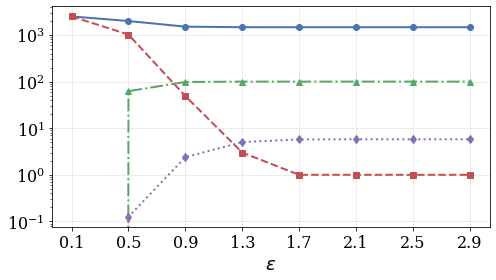

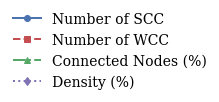

In [ ]:
import matplotlib.pyplot as plt

color_scc = '#4C72B0'  # Muted Blue
color_wcc = '#C44E52'  # Muted Red
color_nodes = '#55A868'  # Muted Green
color_density = '#8172B3'  # Muted Purple
plt.rcParams.update({"font.family": "serif"})

epsilons = list(results.keys())
strongly_connected_components = [results[k]["strongly_connected_components"] for k in epsilons]
weakly_connected_components = [results[k]["weakly_connected_components"] for k in epsilons]
node_connectivity = [results[k]["Percentage_of_connected_nodes"] for k in epsilons]
edge_connectivity = [results[k]["Density"] for k in epsilons]

fig, ax = plt.subplots(figsize=(10, 4))
line1, = ax.plot(epsilons, strongly_connected_components, marker='o', linestyle='-', color=color_scc, label="Number of SCC", linewidth=2, markersize=6)
line2, = ax.plot(epsilons, weakly_connected_components, marker='s', linestyle='--', color=color_wcc, label="Number of WCC", linewidth=2, markersize=6)
line3, = ax.plot(epsilons, node_connectivity, marker='^', linestyle='-.', color=color_nodes, label="Connected Nodes (%)", linewidth=2, markersize=6)
line4, = ax.plot(epsilons, edge_connectivity, marker='d', linestyle=':', color=color_density, label="Density (%)", linewidth=2, markersize=6)

ax.set_xlabel(r"$\varepsilon$", fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=16)
ax.set_yscale('log')
ax.set_xticks(epsilons)
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()

fig.savefig(f"{FACEGroup_DIR}{sep}tmp{sep}{datasetName}{sep}figs{sep}{datasetName}_connectivity_plot_no_legend.pdf", dpi=300)

# Create a separate figure for the legend
fig_legend = plt.figure(figsize=(2, 1))
ax_legend = fig_legend.add_subplot(111)
ax_legend.legend([line1, line2, line3, line4], [line.get_label() for line in [line1, line2, line3, line4]], loc='center', fontsize=14, frameon=False)
ax_legend.axis('off')

fig_legend.tight_layout(pad=1.0)
fig_legend.savefig(f"{FACEGroup_DIR}{sep}tmp{sep}{datasetName}{sep}figs{sep}{datasetName}_legend_e.pdf", bbox_inches='tight', dpi=300)
plt.show()

In [4]:
epsilon = 1.3

# AUC metrics

### (k) AUC related metrics

In [ ]:
max_d = 1.56
upper_limit_for_k = 6

In [ ]:
from metrics import *
saturation_points_k, cov_for_saturation_points_k, auc_matrix_k = kAUC(datasetName=datasetName, epsilon=epsilon,\
    group_identifier='MaxDelqEver', group_identifier_value=5, upper_limit_for_k=upper_limit_for_k,\
    lower_limit_range_for_d=0.1, stepsd=12, stepsk=4, skip_FACEGroup_calculation=True, representation=64)

In [ ]:
plot_k_or_dAUC(datasetName, saturation_points_k, cov_for_saturation_points_k, auc_matrix_k, 'k')

### (d) AUC related metrics

In [ ]:
from metrics import *
saturation_points_d, cov_for_saturation_points_d, auc_matrix_d =dAUC(datasetName=datasetName, epsilon=epsilon, verbose=False,\
    group_identifier='MaxDelqEver', group_identifier_value=5, lower_limit_range_for_d=0.1, \
          upper_limit_for_k=upper_limit_for_k, stepsd=4, stepsk=12, skip_FACEGroup_calculation=True)

In [ ]:
plot_k_or_dAUC(datasetName, saturation_points_d, cov_for_saturation_points_d, auc_matrix_d, 'd')

### (c) AUC related metrics

In [ ]:
from metrics import *
saturation_points_c, cost_for_saturation_points, auc_matrix_c =cAUC(datasetName=datasetName, epsilon=epsilon, verbose=False,\
    group_identifier='MaxDelqEver', group_identifier_value=5, coverage_values = [0.25, 0.5, 0.75, 1], upper_limit_for_k=25,\
    skip_FACEGroup_calculation=True, skip_bandwith_calculation=True, skip_graph_creation=True, skip_distance_calculation=True)

# Testing for different Classifiers

In [ ]:
results = main_cost_constrained_GCFEs(epsilon=epsilon, datasetName=datasetName, group_identifier='MaxDelqEver', group_identifier_value=5, classifier='lr',
                            k=upper_limit_for_k, max_d=max_d, k_selection_method="accross_all_ccs", cost_function = "max_vector_distance",
                            skip_model_training=True, skip_graph_creation=True)[0]

In [ ]:
results = main_cost_constrained_GCFEs(epsilon=epsilon, datasetName=datasetName, group_identifier='MaxDelqEver', group_identifier_value=5, classifier='xgb',
                            k=upper_limit_for_k, max_d=max_d, k_selection_method="accross_all_ccs", cost_function = "max_vector_distance",
                            skip_model_training=True, skip_graph_creation=True)[0]

In [ ]:
results = main_cost_constrained_GCFEs(epsilon=epsilon, datasetName=datasetName, group_identifier='MaxDelqEver', group_identifier_value=5, classifier='dnn',
                            k=upper_limit_for_k, max_d=max_d, k_selection_method="accross_all_ccs", cost_function = "max_vector_distance",
                            skip_model_training=True, skip_graph_creation=True)[0]

# Graph Structure and aWWCs for selected e

In [ ]:
from test_utils import get_graph_stats
get_graph_stats(epsilon=epsilon, datasetName=datasetName, group_identifier='MaxDelqEver', group_identifier_value=5, bandwith_approch="optimal", classifier='xgb')

In [6]:
import networkx as nx
import pickle


with open(f"{FACEGroup_DIR}{sep}tmp{sep}{datasetName}{sep}Graphs{sep}Graph_{epsilon}.pkl", "rb") as file:
    graph = pickle.load(file)

strongly_connected_components = list(nx.strongly_connected_components(graph))
weakly_connected_components = list(nx.weakly_connected_components(graph))

print("Strongly connected components:", len(strongly_connected_components))
print("Weakly connected components:", len(weakly_connected_components))


import json
with open(f"{FACEGroup_DIR}{sep}tmp{sep}{datasetName}{sep}cost_constrained_GCFEs{sep}results_{datasetName}_eps{epsilon}_k_{upper_limit_for_k}_cost_function_max_vector_distance_d_{max_d}_kmethod_accross_all_ccs.json", "r") as file:
    results = json.load(file)

Strongly connected components: 1468
Weakly connected components: 3


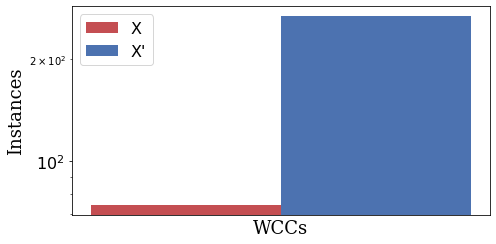

In [7]:
import matplotlib.pyplot as plt
plt.style.use('seaborn-muted')

bar_width = 0.4
fig, ax = plt.subplots(figsize=(7, 3.5))

color_factuals = '#C44E52'  # Muted red
color_cfes = '#4C72B0'  # Muted blue

stats = results['Graph Stats']['0.75_less']
aWCCs = set()
r0 = results['0.75_less']

for fn in r0:
    if fn in ['Coverage', 'Avg. distance', 'Avg. path cost', 'Median distance', 'Median path cost']:
        continue
    aWCCs.add(f"{r0[fn]['cfe_cc']}")

cc_names = [cc for cc in stats if cc.isdigit()]
num_cc = len(cc_names)

bar_gap = 0.5
center_poss = []
labels_added = {'candidate_cfes': False, 'factuals': False}

for j, cc in enumerate(cc_names):
    if cc not in aWCCs:
        continue
    candidate_cfes = stats[cc]['candidate_cfes']
    factuals = stats[cc]['factuals']

    center_pos = j * (2 * bar_width + bar_gap)
    r1 = center_pos - bar_width / 2
    r2 = center_pos + bar_width / 2
    ax.bar(r1, factuals, color=color_factuals, width=bar_width, label='X' if not labels_added['factuals'] else "", zorder=3)
    labels_added['factuals'] = True

    ax.bar(r2, candidate_cfes, color=color_cfes, width=bar_width, label="X'" if not labels_added['candidate_cfes'] else "", zorder=3)
    labels_added['candidate_cfes'] = True

    center_poss.append((r1 + r2) / 2)

ax.set_xticks([])
ax.set_xlabel('WCCs', fontsize=18, fontfamily='serif')
ax.set_ylabel('Instances', fontsize=18, fontfamily='serif')

ax.set_yscale('log')
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)
ax.legend(fontsize=16, frameon=True)
plt.tight_layout()
plt.show()
fig.savefig(f"{FACEGroup_DIR}{sep}tmp{sep}{datasetName}{sep}figs{sep}ccs_candidate_cfes_factuals_g0.pdf", dpi=300)

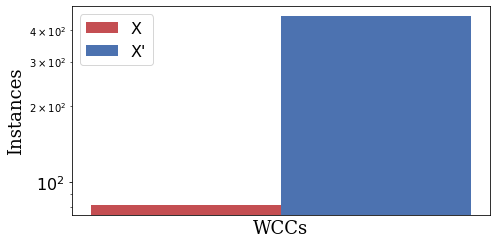

In [9]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-muted')
bar_width = 0.4
fig, ax = plt.subplots(figsize=(7, 3.5))

color_factuals = '#C44E52'  # Muted red
color_cfes = '#4C72B0'  # Muted blue

stats = results['Graph Stats']['0.75_greater']
aWCCs = set()
r0 = results['0.75_greater']

for fn in r0:
    if fn in ['Coverage', 'Avg. distance', 'Avg. path cost', 'Median distance', 'Median path cost']:
        continue
    aWCCs.add(f"{r0[fn]['cfe_cc']}")

cc_names = [cc for cc in stats if cc.isdigit()]
num_cc = len(cc_names)

bar_gap = 0.5
center_poss = []
labels_added = {'candidate_cfes': False, 'factuals': False}

for j, cc in enumerate(cc_names):
    if cc not in aWCCs:
        continue
    candidate_cfes = stats[cc]['candidate_cfes']
    factuals = stats[cc]['factuals']

    center_pos = j * (2 * bar_width + bar_gap)
    r1 = center_pos - bar_width / 2
    r2 = center_pos + bar_width / 2


    ax.bar(r1, factuals, color=color_factuals, width=bar_width, label='X' if not labels_added['factuals'] else "", zorder=3)
    labels_added['factuals'] = True

    ax.bar(r2, candidate_cfes, color=color_cfes, width=bar_width, label="X'" if not labels_added['candidate_cfes'] else "", zorder=3)
    labels_added['candidate_cfes'] = True

    center_poss.append((r1 + r2) / 2)

ax.set_xticks([])
ax.set_xlabel('WCCs', fontsize=18, fontfamily='serif')
ax.set_ylabel('Instances', fontsize=18, fontfamily='serif')

ax.set_yscale('log')
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)
ax.legend(fontsize=16, frameon=True)
plt.tight_layout()
plt.show()
fig.savefig(f"{FACEGroup_DIR}{sep}tmp{sep}{datasetName}{sep}figs{sep}ccs_candidate_cfes_factuals_g1.pdf", dpi=300)